### **Task 4 Easy**

**Setup and paths: Select the computing device and locate the training and validation brain images.**

In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

data_dir = Path("keras_png_slices_data/keras_png_slices_data")

if not data_dir.exists():
    data_dir = Path("..") / data_dir
train_files = sorted((data_dir / "keras_png_slices_train").glob("*.png"))
val_files = sorted((data_dir / "keras_png_slices_validate").glob("*.png"))

print("Device:", device)
print("Training:", len(train_files), "| Validation:", len(val_files))

assert len(train_files) == 9664 and len(val_files) == 1120, "Finish extracting first."

Device: cuda
Training: 9664 | Validation: 1120


**Dataset and batches: Resize the images, scale their pixel values to 0–1, and organise them into batches for the VAE.**

In [3]:
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])

class BrainDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        with Image.open(self.files[index]) as image:
            return transform(image.convert("L"))

train_loader = DataLoader(BrainDataset(train_files), batch_size=128, shuffle=True)
val_loader = DataLoader(BrainDataset(val_files), batch_size=128, shuffle=False)

**Check a batch: Display sample images and verify their dimensions before building the model.**

Batch shape: torch.Size([128, 1, 64, 64])


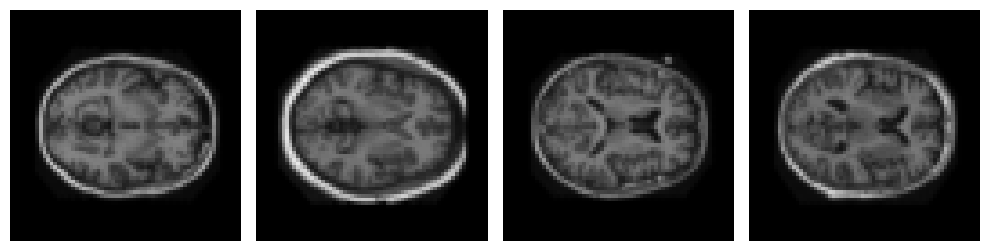

In [4]:
images = next(iter(train_loader))
print("Batch shape:", images.shape)

fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")

plt.tight_layout()
plt.show()